## Lost Insulin horizon experiment

This notebook studies how solution count, reachable policies, planner runtime, and individual timing components change as horizon increases.

Run it in order: define helpers and configurations, execute or load planner runs, build the timing DataFrame, then generate growth and time-distribution plots.


In [1]:
from scripts.AbstractExperiments import ExperimentRunner
from scripts.TexTables import SaveDataFrameToTexTemplate
from copy import deepcopy
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from scipy.stats import linregress
import numpy as np

plt.rcParams.update({
    "font.family": "Charter",
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

def latex_config_name(name):
    formatted = name.replace("Hal", "H")
    formatted = formatted.replace("Carla", "C")
    formatted = formatted.replace("Law", "L")
    formatted = formatted.replace("Necessity", "N")
    return "$" + formatted.replace("^0", "^{0}") + "$"

def QuickPlotGraph(df_, configs:list, 
                   independent_var:str, 
                   dependent_var:str, 
                   title:str=None, 
                   ind_label:str=None, 
                   dep_label:str=None, 
                   file_out:str=None, 
                   regression:bool=False, 
                   regression_label:bool=False,
                   fig_size:tuple=(8,6)):
    if ind_label is None:
        ind_label = independent_var
    if dep_label is None:
        dep_label = dependent_var
        
    df_a = df_.copy()
    df_a = df_a[df_a['Config_name'].isin(configs)]
    df_aa = (
        df_a
        .groupby(["Config_name", independent_var], as_index=False)[dependent_var]
        .mean()
        .sort_values(["Config_name", independent_var])
    )

    regression_results = {}
    regression_text = []

    fig, ax = plt.subplots(figsize=fig_size)
    for c, g in df_aa.groupby('Config_name', sort=False):
        x = g[independent_var].to_numpy(dtype=float)
        y = g[dependent_var].to_numpy(dtype=float)
        ax.scatter(x, y, alpha=0.75, label=latex_config_name(c))
        observed_line, = ax.plot(x, y, alpha=0.75)

        if regression:
            # log(y) is only defined for strictly positive y values.
            valid = (np.isfinite(x) & np.isfinite(y) & (y > 0))
            x_valid = x[valid]
            y_valid = y[valid]
            
            log_y = np.log(y_valid)

            # log(y) = intercept + growth_rate * x
            growth_rate, intercept = np.polyfit(x_valid, log_y, deg=1)

            scale = np.exp(intercept)

            predicted_log_y = (intercept + growth_rate * x_valid)

            residual_sum_of_squares = np.sum((log_y - predicted_log_y) ** 2)
            total_sum_of_squares = np.sum((log_y - log_y.mean()) ** 2)

            if np.isclose(total_sum_of_squares, 0):
                r_squared = np.nan
            else:
                r_squared = (1 - residual_sum_of_squares / total_sum_of_squares)

            regression_results[c] = { "a": scale, "b": growth_rate, "R_squared": r_squared}

            # Use a dense x range to draw a smooth exponential curve.
            regression_x = np.linspace(x_valid.min(), x_valid.max(), 200,)
            regression_y = scale * np.exp(growth_rate * regression_x) 

            ax.plot(
                regression_x,
                regression_y,
                linestyle="--",
                linewidth=2,
                alpha=0.9,
                color=observed_line.get_color(),
                label='__nolegend__',)
            
            regression_text.append(
                rf"{latex_config_name(c)}: "
                rf"$y={scale:.3g}e^{{{growth_rate:.3g}x}}$, "
                rf"$R^2={r_squared:.4f}$"
            )

    plt.yscale('log')  # Set the y-axis to logarithmic scale
    if (title is None):
        plt.title(f"{ind_label} vs {dep_label}")
    else:
        plt.title(title)

    plt.xlabel(ind_label)
    plt.ylabel(dep_label)

    ax.grid(True, alpha=0.3)
    ax.legend(title="Config", loc='upper left')

    if regression and regression_text and regression_label:
        regression_summary = "\n".join(regression_text)
        # Position the regression summary outside the plotting region.
        ax.text(1.03, 0.98, regression_summary,
            transform=ax.transAxes, va="top", ha="left",
            fontsize=11, linespacing=1.4,
            bbox={"boxstyle": "round,pad=0.5", "facecolor": "white", "edgecolor": "0.7", "alpha": 0.9,},
        )
        # Reserve space on the right for the summary.
        fig.subplots_adjust(right=0.68)
    else:
        fig.tight_layout()

    plt.tight_layout() 
    if (not file_out is None):
        plt.savefig(f"{file_out}/{title}.png")
    plt.show()  # Show the plot
    


## Horizon-dependent configurations

**defaultConfig** provides the shared budget. **inputConfigs** defines utilitarian, separate-theory, deontological, and cost-sensitive cases.

The configuration-building loop creates **configs** for horizons 3–10. Each entry includes a horizon-prefixed Name so the experiment runner writes distinct files for each horizon. The configuration-name lists later in this cell select families for particular plots.


In [ ]:
defaultConfig = {"Budget": 3}
inputConfigs = {
    "(AU)": {"Theories": [["AU", "Utility", 0]], "Considerations": [["Overall", "AU"]]},
    "Cost, (AU)": {"Theories": [["AU", "Utility", 0]], "Considerations": [["Overall", "AU"]]},
    "(Hal, Carla)": {"Theories": [["AU", "Utility", 0]], "Considerations": [["Hal", "AU"], ["Carla", "AU"]]},
    "(Hal)^0, (Carla)^0": {"Theories": [["Carla", "Utility", 0], ["Hal", "Utility", 0]], "Considerations": [["Carla", "Carla"], ["Hal", "Hal"]]},
    "(Hal)^0, (Carla)^0, (Hal,Carla)^0": {"Theories": [["Carla", "Utility", 0], ["Hal", "Utility", 0], ["AU", "Utility", 0]], "Considerations": [["Carla",["AU", "Carla"]], ["Hal", ["AU", "Hal"]]]},
    "(HalLife)^0, (CarlaLife)^0, (HalSmall)^1, (CarlaSmall)^1": {
        "Theories": [["HalLife", "Utility", 0], ["CarlaLife", "Utility", 0], ["Hal", "Utility", 1], ["Carla", "Utility", 1]],
        "Considerations": [["CarlaLife", "CarlaLife"], ["HalLife", "HalLife"], ["Carla", "Carla"], ["Hal", "Hal"]]
    },
    "Cost, (HalLife)^0, (CarlaLife)^0, (HalSmall)^1, (CarlaSmall)^1": {
        "Theories": [["HalLife", "Utility", 0], ["CarlaLife", "Utility", 0], ["Hal", "Utility", 1], ["Carla", "Utility", 1]],
        "Considerations": [["CarlaLife", "CarlaLife"], ["HalLife", "HalLife"], ["Carla", "Carla"], ["Hal", "Hal"], ["Cost"]]
    },

    "(L)^0, (H)^1": {
        "Theories": [["Hal", "Utility", 1], ["OrdinalLaw", "Ordinal", 0]], 
        "Considerations": [["Hal", "Hal"], ["OrdinalLaw", "OrdinalLaw"]]
    },
    "(N)^0, (H)^1": {
        "Theories": [["Hal", "Utility", 1], ["Necessity", "Ordinal", 0]], 
        "Considerations": [["Hal", "Hal"], ["Necessity", "Necessity"]]
    },
    "(L)^0, (N)^0, (H)^1": {
        "Theories": [["Hal", "Utility", 1], ["Necessity", "Ordinal", 0], ["OrdinalLaw", "Ordinal", 0]], 
        "Considerations": [["Hal", "Hal"], ["Necessity", "Necessity"], ["OrdinalLaw", "OrdinalLaw"]]
    },

    "(L)^0, (H)^0": {
        "Theories": [["Hal", "Utility", 0], ["OrdinalLaw", "Ordinal", 0]], 
        "Considerations": [["Hal", "Hal"], ["OrdinalLaw", "OrdinalLaw"]]
    },
    "(N)^0, (H)^0": {
        "Theories": [["Hal", "Utility", 0], ["Necessity", "Ordinal", 0]], 
        "Considerations": [["Hal", "Hal"], ["Necessity", "Necessity"]]
    },
    "(L)^0, (N)^0, (H)^0": {
        "Theories": [["Hal", "Utility", 0], ["Necessity", "Ordinal", 0], ["OrdinalLaw", "Ordinal", 0]], 
        "Considerations": [["Hal", "Hal"], ["Necessity", "Necessity"], ["OrdinalLaw", "OrdinalLaw"]]
    },
    "Cost, (L)^0, (N)^0, (H)^0": {
        "Theories": [["Hal", "Utility", 0], ["Necessity", "Ordinal", 0], ["OrdinalLaw", "Ordinal", 0]], 
        "Considerations": [["Hal", "Hal"], ["Necessity", "Necessity"], ["OrdinalLaw", "OrdinalLaw"]]
    },
}
Config_repetitions=1
Environment_repetitions = 10
configs = []
for i in range(3,11):
    for old_name, c in inputConfigs.items():
        c = deepcopy(defaultConfig) | c
        c["Name"] = f"H{i}_{old_name}"
        c["Horizon"] = i
        configs.append(c)
    
Config_repetitions = 1
Environment_repetitions = 10

## Run or extract the experiment

**er** writes to the HorizonExp result folder. The next cell builds environments, runs every configuration for **Environment_repetitions**, and extracts planner fields.

This is the expensive stage. When valid raw files already exist, the build and run lines can be skipped and only extraction/data-loading cells rerun.


In [3]:
er = ExperimentRunner("LostInsulin", configs, MoralPlanner_Location="/../../",outFolder="HorizonExp")
er.buildEnvironments(configRepetitions=1)
er.runPlanner(configRepetitions=Config_repetitions, envRepetitions=Environment_repetitions)
er.extractData(1, Environment_repetitions)

Written LostInsulin MMMDP with 167 states and theories [{'Name': 'AU', 'Type': 'Utility', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/LostInsulin/../../Data/Experiments/LostInsulin/HorizonExp/mdps/H3_(AU)_con0.json

Written LostInsulin MMMDP with 167 states and theories [{'Name': 'AU', 'Type': 'Utility', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/LostInsulin/../../Data/Experiments/LostInsulin/HorizonExp/mdps/H3_(Hal, Carla)_con0.json

Written LostInsulin MMMDP with 167 states and theories [{'Name': 'Carla', 'Type': 'Utility', 'Rank': 0}, {'Name': 'Hal', 'Type': 'Utility', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/LostInsulin/../../Data/Experiments/LostInsulin/HorizonExp/mdps/H3_(Hal)^0, (Carla)^0_con0.json

Written LostInsulin MMMDP with 167 states and theories [{'Name': 'Carla', 'Type': 'Utility', 'Rank': 0}, {'Name': 'Hal', 'Type': 'Utility', 'Rank': 0}, {'Name': 'AU', 'Type': 'Utility', 'Rank': 0}].
PATH  /home/psi

## Build the runtime DataFrame

This cell reads each raw planner JSON file and creates **df**, with one row per configuration/environment repetition.

| Column group | Contents |
|---|---|
| Identifiers | Config_name, Env_rep, Horizon |
| Timing | Heuristic, Plan, Solution Extraction, MEHR, Total |
| Search size | Solutions and Total policies |

Configuration names are shortened after loading. The lists **util_configs**, **deon_configs**, and **non_moral_configs** control which series appear in later graphs.


In [ ]:
data = []
for c in configs:
    for env_rep in range(Environment_repetitions):
        # Assuming self.makePlanOutFileName exists
        outFile = er.makePlanOutFileName(c["Name"], 0, env_rep)
        with open(outFile, 'r') as file:
            json_data = json.load(file)
            e = {
                "Config_name": c["Name"],
                "Env_rep" : env_rep,
                "Horizon": json_data["Horizon"],
                "Heuristic": json_data["Duration_Heuristic"],
                "Plan": json_data["Duration_Plan"],
                "Solution Extraction": json_data["Duration_Sols"],
                "MEHR": json_data["Duration_MEHR"],
                "Total" : json_data["Duration_Total"],
                "Total" : json_data["Duration_Total"],
                "Solutions" : len(json_data["Solutions"]),
                "Total policies": json_data["Total_reachable_policies"]
            }
            data.append(e)
time_cols = ["Heuristic", "Plan", "Solution Extraction", "MEHR", "Total"]
df = pd.DataFrame(data)
df["Config_name"] = df["Config_name"].str.split("_").str[-1]

df['Config_name'] = df['Config_name'].str.replace("HalLife", "HL")
df['Config_name'] = df['Config_name'].str.replace("CarlaLife", "CL")
df['Config_name'] = df['Config_name'].str.replace("HalSmall", "HS")
df['Config_name'] = df['Config_name'].str.replace("CarlaSmall", "CS")
df['Config_name'] = df['Config_name'].str.replace("Hal", "H")
df['Config_name'] = df['Config_name'].str.replace("Carla", "C")
df['Config_name'] = df['Config_name'].str.replace("Law", "L")
df['Config_name'] = df['Config_name'].str.replace("Necessity", "N")
util_configs = ['(AU)', '(H, C)', '(H)^0, (C)^0', '(H)^0, (C)^0, (H,C)^0', '(HL)^0, (CL)^0, (HS)^1, (CS)^1',]
deon_configs = ["(AU)",
    "(L)^0, (H)^0", "(L)^0, (N)^0",
                "(L)^0, (N)^0, (H)^0",
                "(L)^0, (H)^1", "(L)^0, (N)^1", 
                "(L)^0, (N)^0, (H)^1"]
non_moral_configs = ["(AU)", "Cost, (AU)", 
                     '(HL)^0, (CL)^0, (HS)^1, (CS)^1', 'Cost, (HL)^0, (CL)^0, (HS)^1, (CS)^1',
                     ]

df.head(10)

,Config_name,Env_rep,Horizon,Heuristic,Plan,Solution Extraction,MEHR,Total,Solutions,Total policies
0,(AU),0,4,53,35,50,0,138,1,811
1,(AU),1,4,46,28,38,0,112,1,811
2,(AU),2,4,41,28,34,0,103,1,811
3,(AU),3,4,51,34,47,0,132,1,811
4,(AU),4,4,41,27,37,0,105,1,811
5,(AU),5,4,42,27,38,0,107,1,811
6,(AU),6,4,41,27,37,0,105,1,811
7,(AU),7,4,42,27,37,0,106,1,811
8,(AU),8,4,41,27,37,0,105,1,811
9,(AU),9,4,36,24,30,0,90,1,811


## Horizon growth and exponential regression

**QuickPlotGraph** groups **df** by configuration and the selected independent variable before plotting mean values.

When regression is enabled, it fits \(y = ae^{bx}\) using positive observations, draws the fitted curve, and can display its parameters and \(R^2\). The next cells apply it to policy count and total/component CPU time.


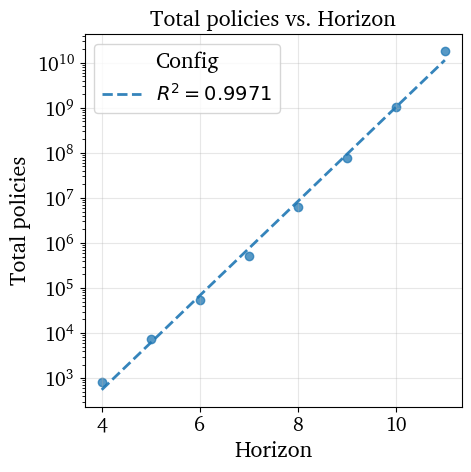

In [39]:
title="Total policies vs. Horizon"
file_out=er.figuresFolder
regression=True
independent_var = "Horizon"
dependent_var = "Total policies"
df_a = df.copy()
df_a = df_a[df_a['Config_name'].isin(["(AU)"])]
df_aa = (
    df_a
    .groupby(["Config_name", independent_var], as_index=False)[dependent_var]
    .mean()
    .sort_values(["Config_name", independent_var])
)

regression_results = {}
fig, ax = plt.subplots(figsize=(5, 5))
for c, g in df_aa.groupby('Config_name', sort=False):
    x = g[independent_var].to_numpy(dtype=float)
    y = g[dependent_var].to_numpy(dtype=float)
    ax.scatter(x, y, alpha=0.75)

    if regression:
        # log(y) is only defined for strictly positive y values.
        valid = (np.isfinite(x) & np.isfinite(y) & (y > 0))
        x_valid = x[valid]
        y_valid = y[valid]
        
        log_y = np.log(y_valid)

        # log(y) = intercept + growth_rate * x
        growth_rate, intercept = np.polyfit(x_valid, log_y, deg=1)

        scale = np.exp(intercept)

        predicted_log_y = (intercept + growth_rate * x_valid)

        residual_sum_of_squares = np.sum((log_y - predicted_log_y) ** 2)
        total_sum_of_squares = np.sum((log_y - log_y.mean()) ** 2)

        if np.isclose(total_sum_of_squares, 0):
            r_squared = np.nan
        else:
            r_squared = (1 - residual_sum_of_squares / total_sum_of_squares)

        regression_results[c] = { "a": scale, "b": growth_rate, "R_squared": r_squared}

        # Use a dense x range to draw a smooth exponential curve.
        regression_x = np.linspace(x_valid.min(), x_valid.max(), 200,)
        regression_y = scale * np.exp(growth_rate * regression_x) 

        regression_label = rf"$R^2={r_squared:.4f}$"

        ax.plot(
            regression_x,
            regression_y,
            linestyle="--",
            linewidth=2,
            alpha=0.9,
            label=regression_label,)

plt.yscale('log')  # Set the y-axis to logarithmic scale

plt.title(title)

plt.xlabel(independent_var)
plt.ylabel(dependent_var)

ax.grid(True, alpha=0.3)
ax.legend(title="Config", loc='upper left')

plt.tight_layout() 
if (not file_out is None):
    plt.savefig(f"{file_out}/{title}.png")
plt.show()  # Show the plot


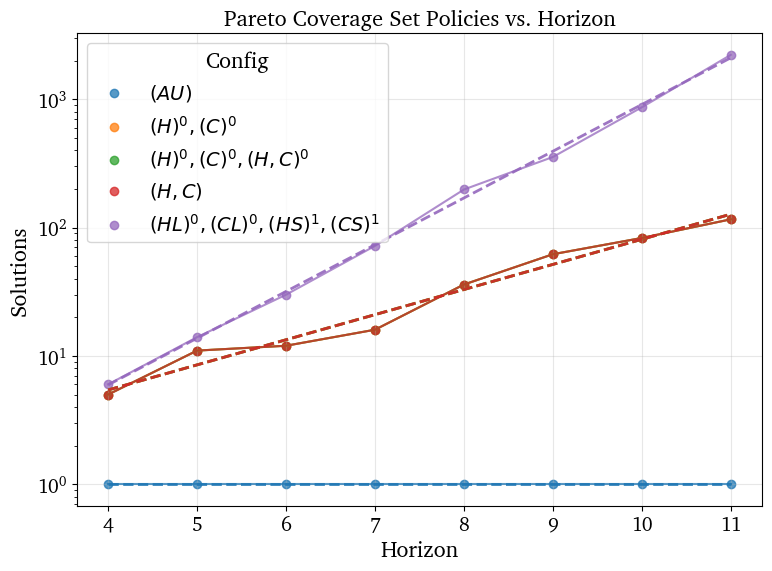

In [40]:
QuickPlotGraph(df, util_configs, "Horizon", "Solutions", title="Pareto Coverage Set Policies vs. Horizon", file_out=er.figuresFolder, regression=True)

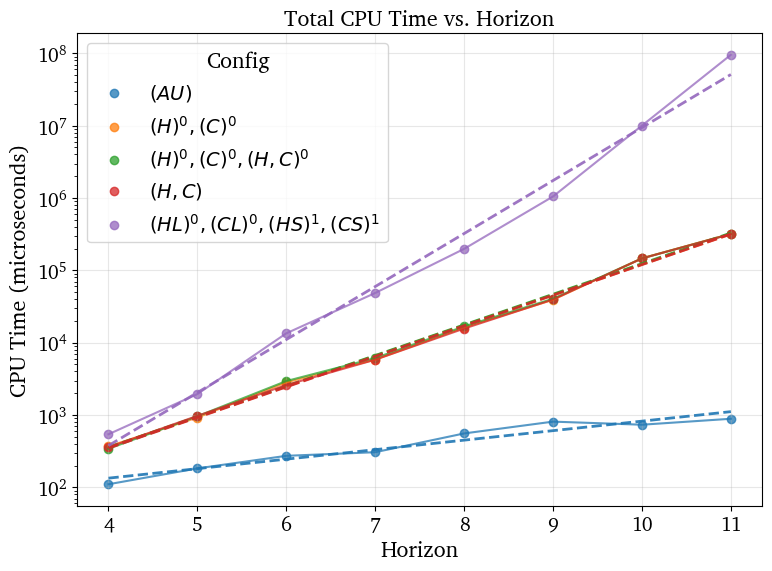

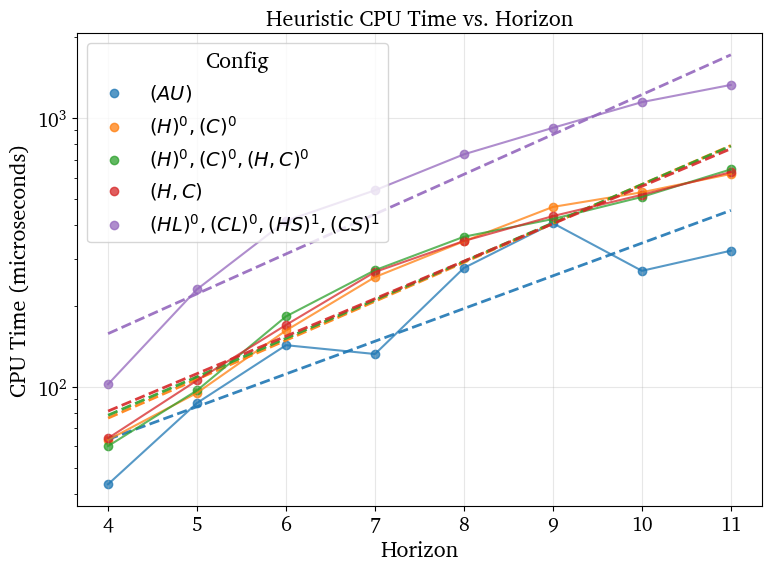

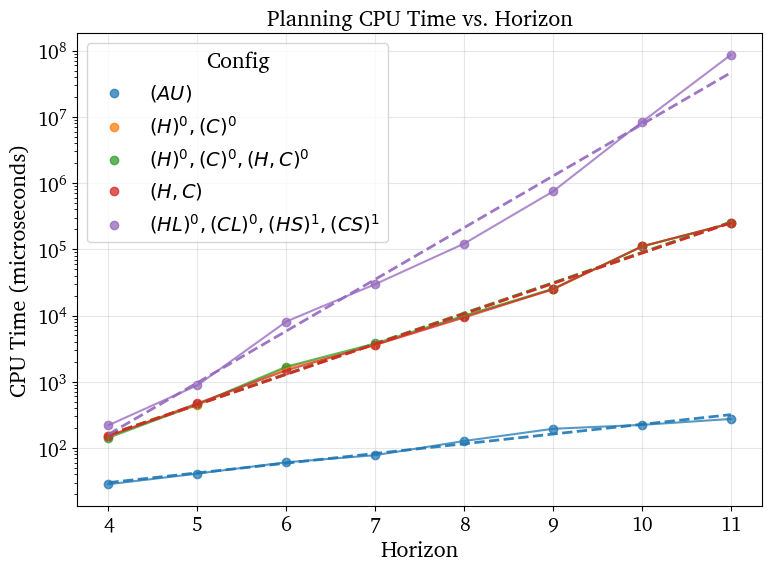

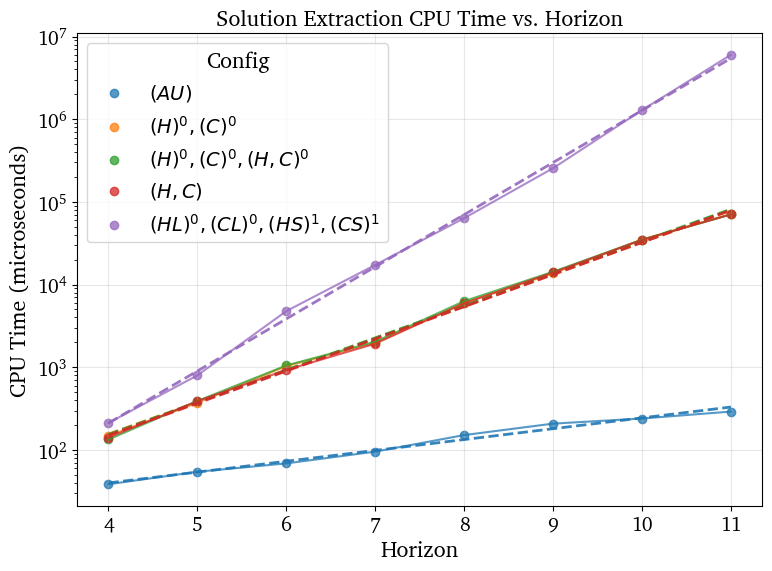

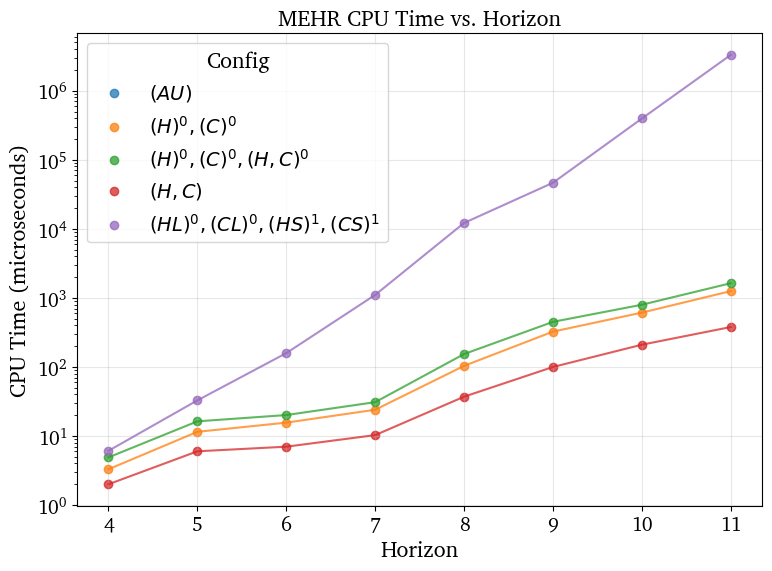

In [41]:
r = True
rl = False
QuickPlotGraph(df, util_configs, "Horizon", "Total", title="Total CPU Time vs. Horizon", dep_label="CPU Time (microseconds)", file_out=er.figuresFolder, regression=r, regression_label=rl)
QuickPlotGraph(df, util_configs, "Horizon", "Heuristic", title="Heuristic CPU Time vs. Horizon", dep_label="CPU Time (microseconds)", file_out=er.figuresFolder, regression=r, regression_label=rl)
QuickPlotGraph(df, util_configs, "Horizon", "Plan", title="Planning CPU Time vs. Horizon", dep_label="CPU Time (microseconds)", file_out=er.figuresFolder, regression=r, regression_label=rl)
QuickPlotGraph(df, util_configs, "Horizon", "Solution Extraction", title="Solution Extraction CPU Time vs. Horizon", dep_label="CPU Time (microseconds)", file_out=er.figuresFolder, regression=r, regression_label=rl)
QuickPlotGraph(df, util_configs, "Horizon", "MEHR", title="MEHR CPU Time vs. Horizon", dep_label="CPU Time (microseconds)", file_out=er.figuresFolder)

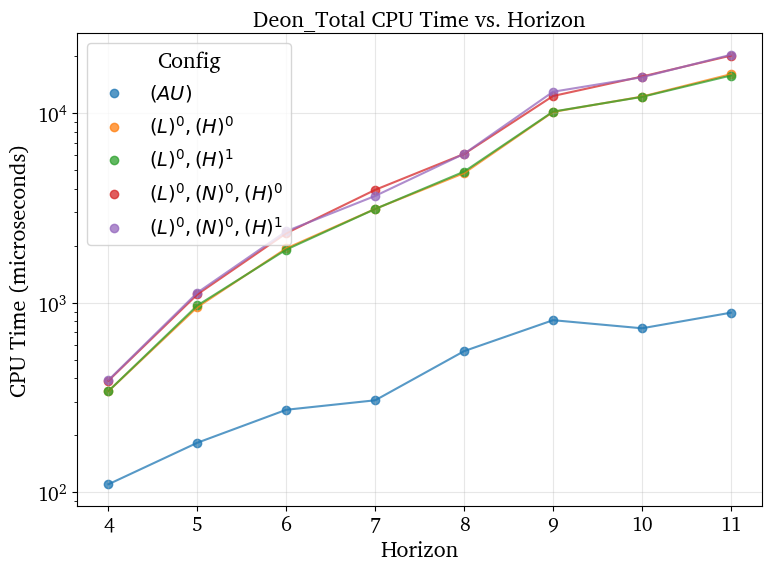

In [56]:
QuickPlotGraph(df, deon_configs, "Horizon", "Total", title="Deon_Total CPU Time vs. Horizon", dep_label="CPU Time (microseconds)", file_out=er.figuresFolder)

## Timing composition

The bar chart averages timing categories across selected configurations.

**mean_time_graph** converts each component into a percentage of Total for every run, then averages those percentages by horizon. **average_percentages** performs a related configuration-level aggregation. These views show where planner time is spent rather than only how total runtime grows.


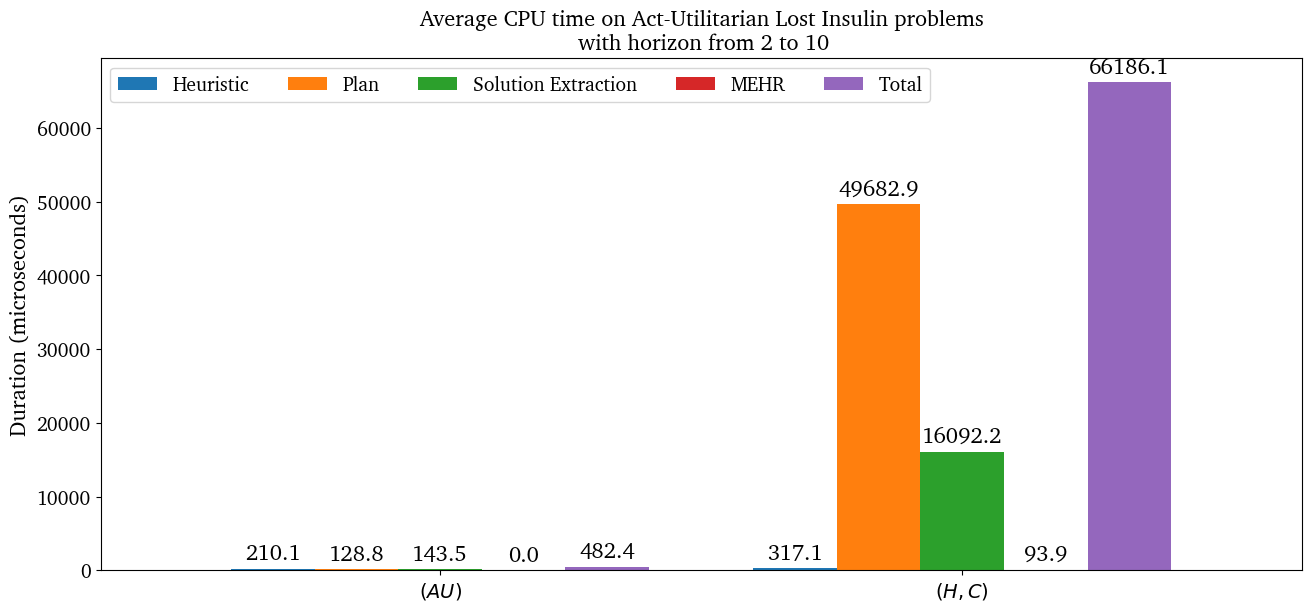

In [43]:
import re
time_categories = ['Heuristic', 'Plan', 'Solution Extraction', 'MEHR', 'Total']

df_b = df[df['Config_name'].isin(["(AU)", "(H, C)"])]

averages = df_b.groupby('Config_name', sort=False)[time_categories].mean()


fig, ax = plt.subplots(layout='constrained', figsize=(13, 6))

averages.plot.bar(ax=ax, width=0.8, rot=0)
ax.set_xticklabels([
    latex_config_name(label.get_text())
    for label in ax.get_xticklabels()
])

for container in ax.containers:
    formatted_label = re.sub(r"\^(\d)", r"$^{\1}$", str(container))
    ax.bar_label(container, padding=3, fmt='%.1f')
    
ax.set_ylabel('Duration (microseconds)')
ax.set_xlabel('')
ax.set_title('Average CPU time on Act-Utilitarian Lost Insulin problems\n with horizon from 2 to 10')

ax.legend(loc='upper left', ncols=5)
ax.set_ylim(0, averages['Total'].max() * 1.05)

plt.savefig(f"{er.figuresFolder}/TimeGraph.png", dpi=300)
plt.show()

In [44]:
def mean_time_graph(df, config_name, file_out=None, title=None, fig_size:tuple=(8,6)):
    time_categories = [
        "Heuristic",
        "Plan",
        "Solution Extraction",
        "MEHR"
    ]

    df_a = df[df["Config_name"] == config_name].copy()

    # Percentage of total time taken by each category for each run
    percentage_columns = []

    for category in time_categories:
        percentage_column = f"{category}_percent"

        df_a[percentage_column] = (
            df_a[category]
            .div(df_a["Total"])
            .mul(100)
        )

        percentage_columns.append(percentage_column)

    # Mean percentage at each horizon
    mean_percentages = (
        df_a
        .groupby("Horizon", as_index=False)[percentage_columns]
        .mean()
        .sort_values("Horizon")
    )
    fig, ax = plt.subplots(figsize=fig_size)

    for category, percentage_column in zip(
        time_categories,
        percentage_columns
    ):
        ax.scatter(
            mean_percentages["Horizon"],
            mean_percentages[percentage_column],
            alpha=0.75
        )

        ax.plot(
            mean_percentages["Horizon"],
            mean_percentages[percentage_column],
            alpha=0.75,
            label=category
        )

    if title is None:
        title = f"Mean CPU time distribution vs Horizon\n{latex_config_name(config_name)}"
    
    ax.set_title(title)
    ax.set_xlabel("Horizon")
    ax.set_ylabel("Mean percentage of total CPU time")

    ax.set_ylim(0, 100)
    ax.set_xticks(sorted(mean_percentages["Horizon"].unique()))

    ax.grid(True, alpha=0.3)
    ax.legend(title="Time category", loc="best")

    plt.tight_layout()
    if (not file_out is None):
        if (file_out.find('.png') != -1):
            plt.savefig(f"{file_out}")
        else:
            plt.savefig(rf"{file_out}/{title.replace('$','')}.png")

    plt.show()


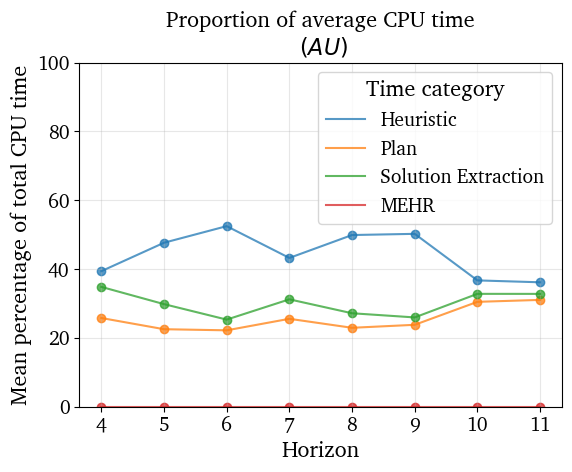

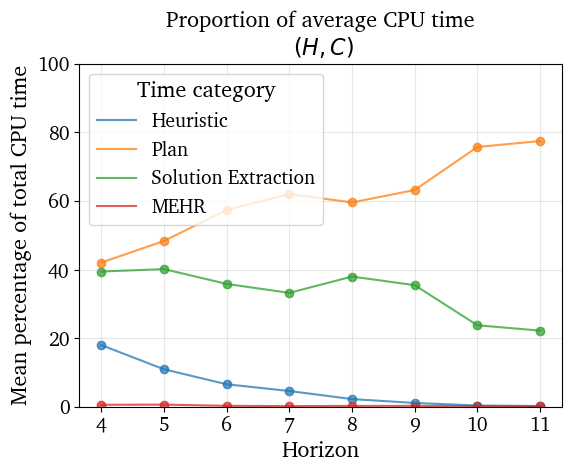

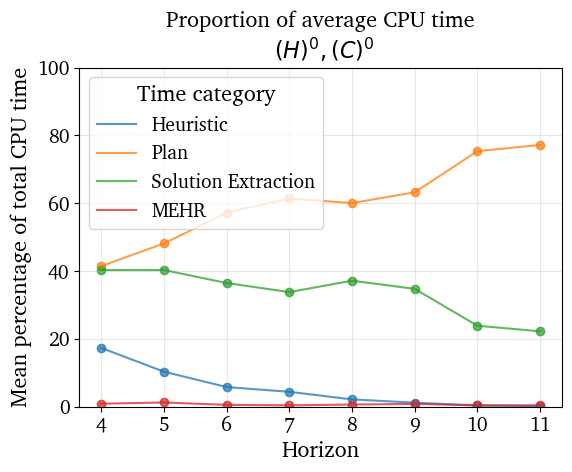

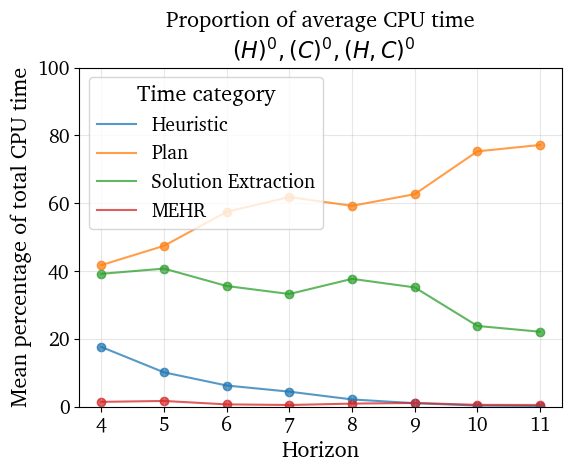

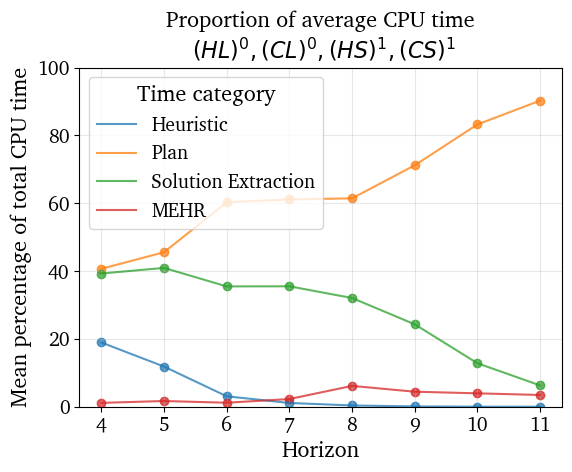

In [45]:
for u in util_configs:
    mean_time_graph(df, u, title=f"Proportion of average CPU time\n {latex_config_name(u)}", fig_size=(6,5), file_out=f"{er.figuresFolder}/Percents_{u}.png")

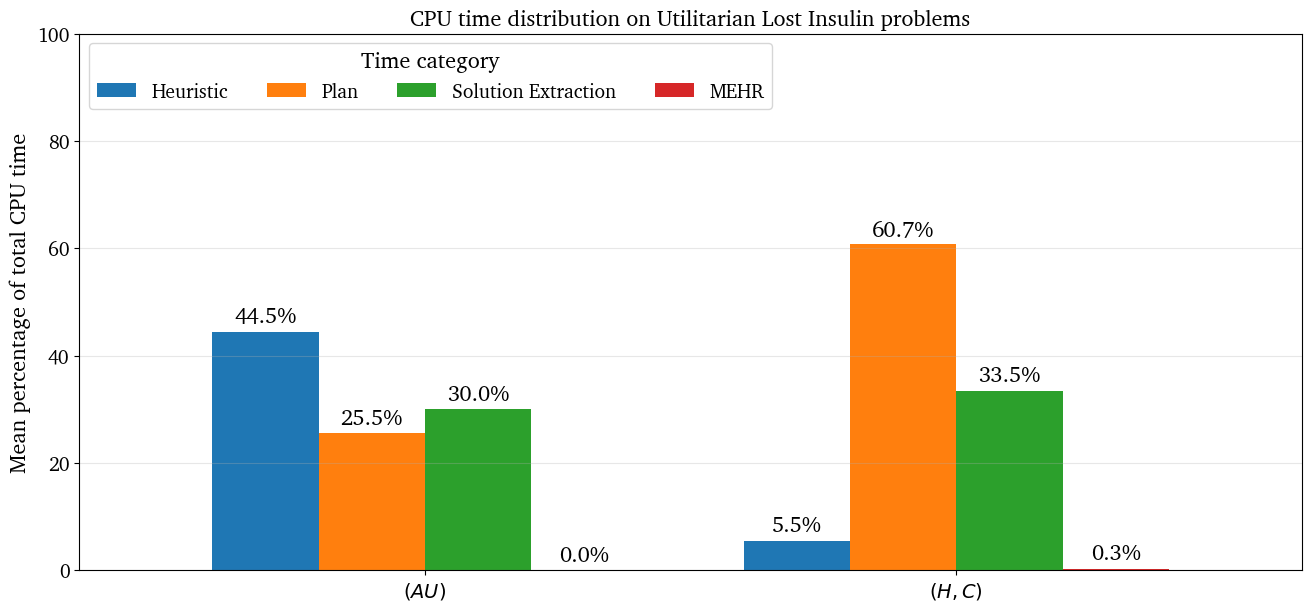

In [46]:
no_total_time_categories = [
    "Heuristic",
    "Plan",
    "Solution Extraction",
    "MEHR"
]

df_df_ba = df[df['Config_name']!="(HalLife)^0, (CaraLife)^0"].copy()

# Convert each time category to a percentage of Total for that run
df_b[no_total_time_categories] = (df_b[no_total_time_categories].div(df_b["Total"], axis=0).mul(100))

# Mean percentage for each configuration
average_percentages = (
    df_b
    .groupby("Config_name", sort=False)[no_total_time_categories]
    .mean()
)

fig, ax = plt.subplots(layout="constrained", figsize=(13, 6))

average_percentages.plot.bar(
    ax=ax,
    width=0.8,
    rot=0
)
ax.set_xticklabels([
    latex_config_name(label.get_text())
    for label in ax.get_xticklabels()
])

for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
        fmt="%.1f%%"
    )

ax.set_ylabel("Mean percentage of total CPU time")
ax.set_xlabel("")
ax.set_title("CPU time distribution on Utilitarian Lost Insulin problems")

ax.legend(
    title="Time category",
    loc="upper left",
    ncols=4
)

ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)

plt.savefig(
    f"{er.figuresFolder}/TimePercentageGraph.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## MDP-size properties

This section replaces **df** with a different DataFrame read from the raw JSON files. It contains Horizon, Env_rep, Total Solutions, Total Backups, Total Attacks, and Total States.

**averages_props** averages those structural measurements by horizon and plots them on a logarithmic scale. Because **df** is reassigned here, rerun the runtime-data cell before returning to earlier timing plots.


In [ ]:
data = []
for c in configs:
    for env_rep in range(Environment_repetitions):
        # Assuming self.makePlanOutFileName exists
        outFile = er.makePlanOutFileName(c["Name"], 0, env_rep)
        with open(outFile, 'r') as file:
            json_data = json.load(file)
            data.append([json_data["Horizon"], env_rep, 
                            len(json_data["Solutions"]),
                            json_data["Backups"],
                            json_data["Total_Attacks"],
                            json_data["Total_states"]])
            
props_cols = ["Total Solutions", "Total Backups", "Total Attacks", "Total States"]
cols = ["Horizon", "Env_rep"] + props_cols
df = pd.DataFrame(data, columns=cols)

In [48]:
averages_props = df.groupby('Horizon')[props_cols].mean().reset_index()

plt.figure(figsize=(10, 6))

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i, column in enumerate(props_cols):
    current_color = colors[i % len(colors)]
    
    plt.scatter(average_durations['Horizon'], averages_props[column], color=current_color, label=column)

    # Calculate best fit line
    x = averages_props['Horizon']
    y = averages_props[column]
    slope, intercept, r_value, _, _ = linregress(x, np.log10(y))  # Fit line in log scale
    best_fit_line = 10 ** (slope * x + intercept)  # Transform back to original scale    
    plt.plot(x, best_fit_line, linestyle='--', color=current_color, alpha=0.8, label=f'{column} Best Fit (R={r_value:.2f})')

plt.yscale('log')  # Set the y-axis to logarithmic scale
plt.title("Horizon vs MDP Properties (Logarithmic Scale)")
plt.xlabel("Horizon")
plt.xticks(ticks=np.arange(min(averages_props['Horizon']), max(averages_props['Horizon']) + 1, 1))

# Optional: move legend outside if it gets too cluttered with double labels
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 

plt.tight_layout() # Ensures the legend isn't cut off if moved outside
plt.savefig(er.outputFolder + "propsVHorizon_LOG_SCALE.png")  # Save the plot
plt.show()  # Show the plot

NameError: name 'average_durations' is not defined

<Figure size 1000x600 with 0 Axes>

In [ ]:
cols = ["Config_name", 'Hal_Utility', 'Carla_Utility', "Min_non_accept", "Num_of_min_non_accept", "Num_of_sols", "Total_time"]
df = pd.DataFrame(er.data, columns=["Horizon", "Env_rep", 'Hal', 'Carla'])

df = df.replace(["", "N/A", "NA", "nan", "None"], np.nan)
df.head(100)



,Horizon,Env_rep,Hal,Carla
0,5,0,-68.9674,0
1,5,1,-68.9674,0
2,5,2,-68.9674,0
3,5,3,-68.9674,0
4,5,4,-68.9674,0
...,...,...,...,...
95,11,5,-49.2727,-15.4549
96,11,6,-49.2727,-15.4549
97,11,7,-49.2727,-15.4549
98,11,8,-49.2727,-15.4549


: 